# Lab | Variational Autoencoder (VAE) on Fashion-MNIST Dataset

In [117]:
import tensorflow as tf
from tensorflow.keras import layers, Model, datasets
from tensorflow.keras.optimizers import Adam
### YOUR CODE HERE
# Figure out how to import regularizers and backend
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

Training data shape: (60000, 784)
Test data shape: (10000, 784)


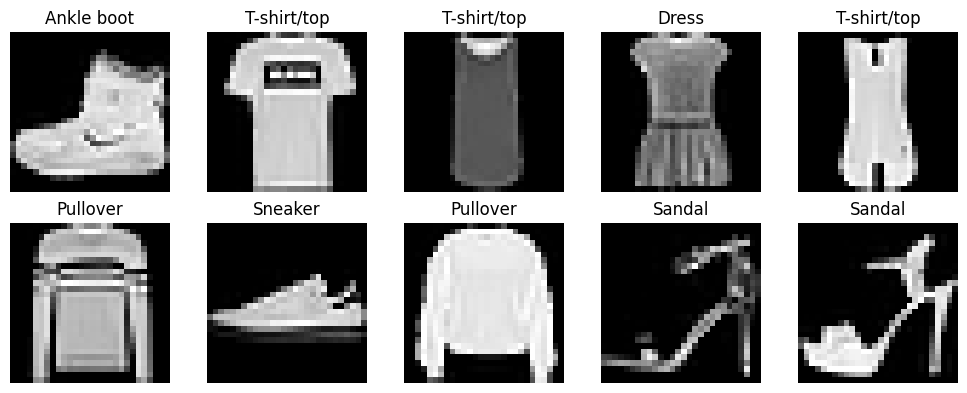

In [118]:
# Load and preprocess Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to flatten the images
x_train = x_train.reshape(x_train.shape[0], 28 * 28)
x_test = x_test.reshape(x_test.shape[0], 28 * 28)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Fashion-MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [119]:
# Sampling layer for the VAE
#TODO: YOUR CODE HERE
class Sampling(layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        epsilon = K.random_normal(shape=K.shape(mean))
        return mean + K.exp(0.5 * log_var) * epsilon

In [120]:
# Build the encoder
latent_dim = 2  # 2D latent space for easy visualization
original_dim = 28 * 28
#TODO: YOUR CODE HERE

encoder_input = layers.Input(shape=(original_dim,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)

mean = layers.Dense(latent_dim, name='mean')(x)
log_var = layers.Dense(latent_dim, name='log_var')(x)

z = Sampling()([mean, log_var])

encoder = Model(encoder_input, [mean, log_var, z], name='encoder')

In [121]:
# Build the decoder

decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dense(512, activation='relu')(x)
# Output probabilities (sigmoid) – suitable for binary cross‑entropy
decoder_output = layers.Dense(original_dim, activation='sigmoid')(x)

decoder = Model(decoder_input, decoder_output, name='decoder')


In [122]:
# Build the VAE model
#TODO: YOUR CODE HERE
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def _extract_input(self, data):
        """Extract the input tensor from data (supports both tuple and single tensor)."""
        if isinstance(data, (tuple, list)):
            return data[0]
        return data

    def call(self, inputs, training=None):
        """Forward pass: encode -> sample -> decode."""
        mean, log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        x = self._extract_input(data)

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)

            recon_loss_per_sample = tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(x, reconstruction),
                axis=-1
            )
            reconstruction_loss = tf.reduce_mean(recon_loss_per_sample)

            kl_loss_per_sample = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=-1
            )
            kl_loss = tf.reduce_mean(kl_loss_per_sample) * self.beta

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = self._extract_input(data)

        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        recon_loss_per_sample = tf.reduce_sum(
            tf.keras.losses.binary_crossentropy(x, reconstruction),
            axis=-1
        )
        reconstruction_loss = tf.reduce_mean(recon_loss_per_sample)

        kl_loss_per_sample = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=-1
        )
        kl_loss = tf.reduce_mean(kl_loss_per_sample) * self.beta

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Instantiate the VAE
vae = VAE(encoder, decoder)

In [123]:
# Train the VAE
#TODO: YOUR CODE HERE
vae.compile(optimizer=Adam(learning_rate=1e-3))

history = vae.fit(
    x_train,               # only inputs; targets are not needed because loss is computed inside
    epochs=50,
    batch_size=128,
    validation_data=(x_test, x_test)  # validation data as tuple (inputs, targets) – will be handled
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - kl_loss: 2.9248 - loss: 52.1168 - reconstruction_loss: 49.1920 - val_kl_loss: 3.2739 - val_loss: 48.4743 - val_reconstruction_loss: 45.2004
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.5126 - loss: 48.1737 - reconstruction_loss: 44.6612 - val_kl_loss: 3.5172 - val_loss: 47.4527 - val_reconstruction_loss: 43.9355
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 3.6618 - loss: 47.4973 - reconstruction_loss: 43.8354 - val_kl_loss: 3.6672 - val_loss: 47.0605 - val_reconstruction_loss: 43.3933
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 3.7375 - loss: 47.1634 - reconstruction_loss: 43.4259 - val_kl_loss: 3.5027 - val_loss: 46.8793 - val_reconstruction_loss: 43.3766
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - kl_loss: 3.7958 - loss: 46.9842 - reconstruction_loss: 43.1884 - val_kl_loss: 3.8524 - val_loss: 46.6113 - val_reconstruction_loss: 42.7590
Epoch 6/50
469/469 ━━━━

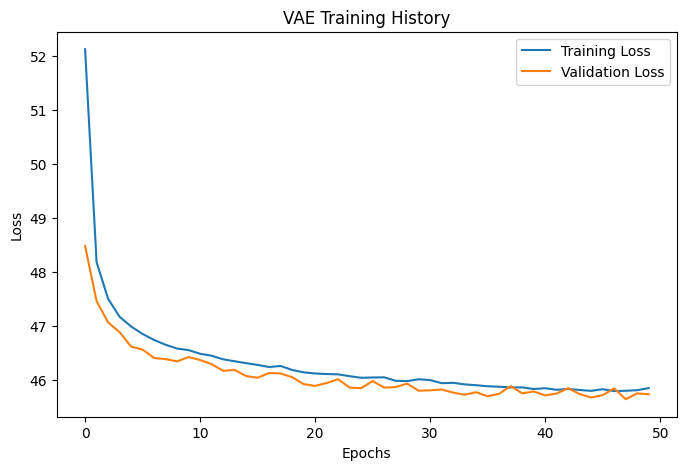

In [124]:
# Plot training history
#TODO: YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('VAE Training History')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


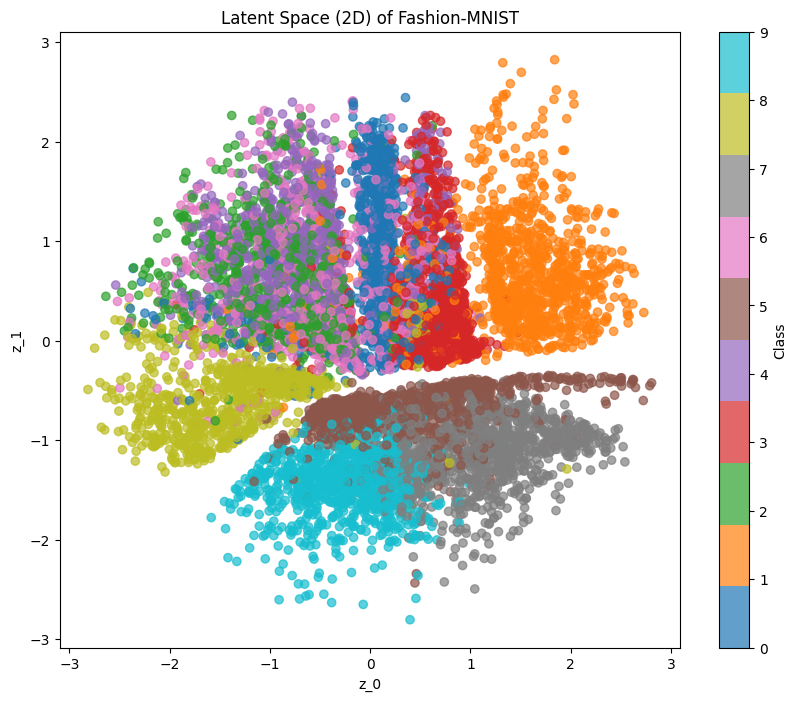

In [125]:
# Visualize the latent space
#TODO: YOUR CODE HERE
means, _, _ = vae.encoder.predict(x_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(means[:, 0], means[:, 1], c=y_test, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.title('Latent Space (2D) of Fashion-MNIST')
plt.xlabel('z_0')
plt.ylabel('z_1')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


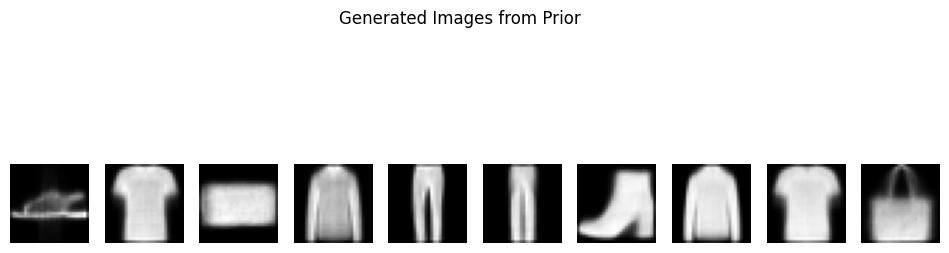

In [126]:
#####################################################
# Generate new images by sampling from latent space #
#####################################################

### YOUR CODE HERE
n = 10
z_sample = np.random.normal(0, 1, size=(n, latent_dim))
generated = vae.decoder.predict(z_sample)

plt.figure(figsize=(12, 4))
for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(generated[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Images from Prior')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


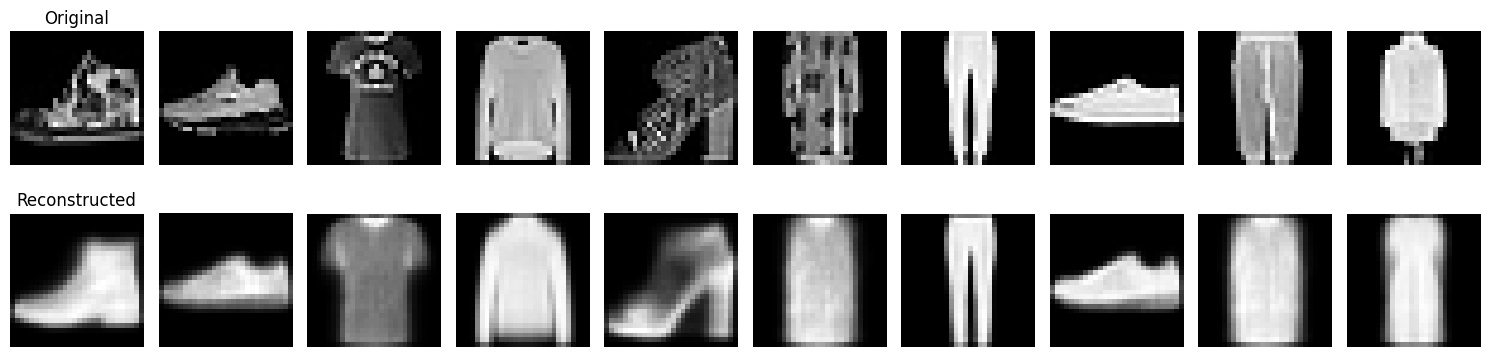

In [127]:
#############################################
# Compare original vs reconstructed images  #
#############################################


### YOUR CODE HERE
n = 10
indices = np.random.choice(len(x_test), n, replace=False)
x_test_selected = x_test[indices]
reconstructed = vae.predict(x_test_selected)   # now works because `call` is defined

plt.figure(figsize=(15, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test_selected[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Original')
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Reconstructed')
plt.tight_layout()
plt.show()